# Lab 10: Data Normalization Techniques
## IBM Data Analytics Capstone Project 
### Objective: Normalize compensation data using Min-Max Scaling and Z-score Normalization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

print(" Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [2]:
# Identify duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("Duplicates handled!")

Duplicate rows: 0
Shape after removing duplicates: (65437, 114)
Duplicates handled!


In [3]:
# Task 2: Missing values in RemoteWork
print("Missing values in RemoteWork:", df['RemoteWork'].isnull().sum())

# Impute RemoteWork with most frequent value
most_frequent_remote = df['RemoteWork'].value_counts().idxmax()
df['RemoteWork'] = df['RemoteWork'].fillna(most_frequent_remote)
print("After imputation - Missing in RemoteWork:", df['RemoteWork'].isnull().sum())
print("RemoteWork imputed with:", most_frequent_remote)

# Task 3: Missing values in CodingActivities
print("\nMissing values in CodingActivities:", df['CodingActivities'].isnull().sum())

# Impute with forward fill
df['CodingActivities'] = df['CodingActivities'].ffill()
print("After forward-fill - Missing in CodingActivities:", df['CodingActivities'].isnull().sum())
print("CodingActivities imputed with forward-fill!")

Missing values in RemoteWork: 10631
After imputation - Missing in RemoteWork: 0
RemoteWork imputed with: Hybrid (some remote, some in-person)

Missing values in CodingActivities: 10971
After forward-fill - Missing in CodingActivities: 0
CodingActivities imputed with forward-fill!


In [4]:
# Task 4: Identify compensation-related columns
comp_cols = [col for col in df.columns if 'comp' in col.lower() or 'salary' in col.lower()]
print("Compensation-related columns:", comp_cols)

# Handle missing values in ConvertedCompYearly
print("\nMissing in ConvertedCompYearly:", df['ConvertedCompYearly'].isnull().sum())
median_comp = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median_comp)
print("After imputation - Missing:", df['ConvertedCompYearly'].isnull().sum())
print("Median used:", median_comp)

Compensation-related columns: ['CompTotal', 'AIComplex', 'ConvertedCompYearly']

Missing in ConvertedCompYearly: 42002
After imputation - Missing: 0
Median used: 65000.0


In [5]:
# Task 5: Min-Max Scaling
min_val = df['ConvertedCompYearly'].min()
max_val = df['ConvertedCompYearly'].max()

df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - min_val) / (max_val - min_val)

print("Min-Max Normalization applied!")
print(df['ConvertedCompYearly_MinMax'].describe())

Min-Max Normalization applied!
count    65437.000000
mean         0.004464
std          0.006903
min          0.000000
25%          0.003998
50%          0.003998
75%          0.003998
max          1.000000
Name: ConvertedCompYearly_MinMax, dtype: float64


In [6]:
# Task 6: Z-score Normalization
mean_val = df['ConvertedCompYearly'].mean()
std_val = df['ConvertedCompYearly'].std()

df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - mean_val) / std_val

print("Z-score Normalization applied!")
print(df['ConvertedCompYearly_Zscore'].describe())

Z-score Normalization applied!
count    6.543700e+04
mean    -5.733248e-17
std      1.000000e+00
min     -6.467200e-01
25%     -6.751303e-02
50%     -6.751303e-02
75%     -6.751303e-02
max      1.442161e+02
Name: ConvertedCompYearly_Zscore, dtype: float64


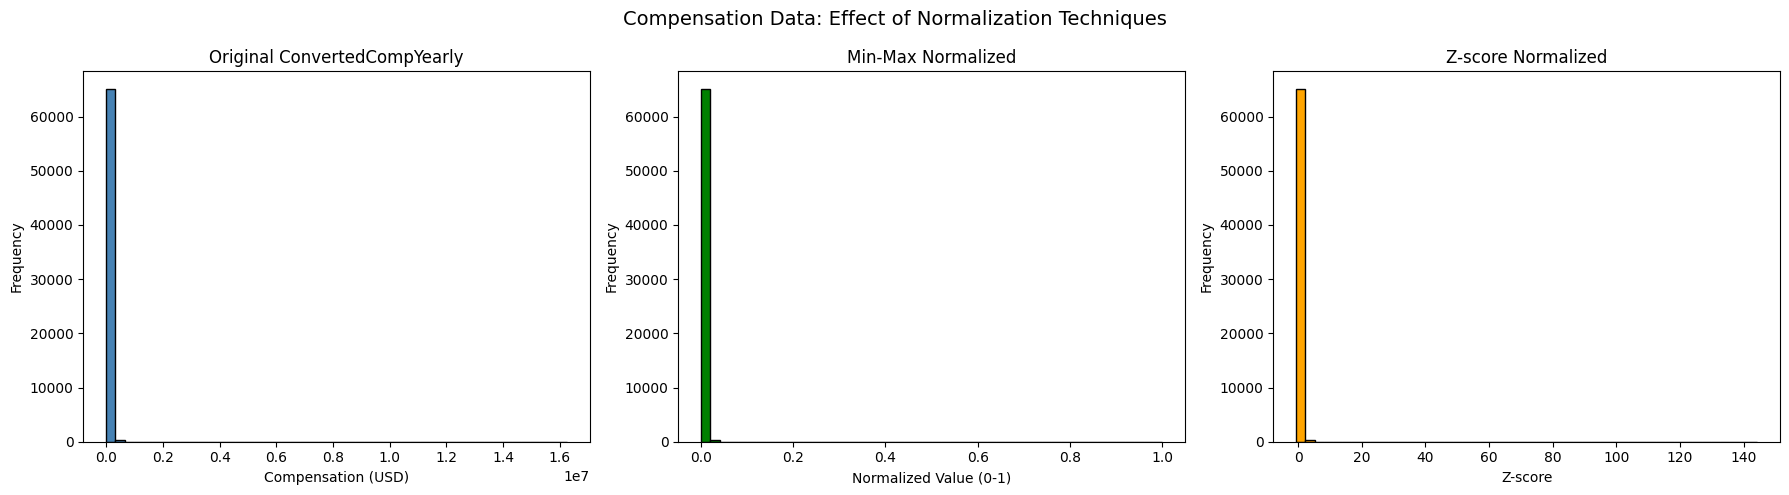

Visualization saved!


In [7]:
# Task 7: Visualize original vs normalized distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
axes[0].hist(df['ConvertedCompYearly'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Original ConvertedCompYearly')
axes[0].set_xlabel('Compensation (USD)')
axes[0].set_ylabel('Frequency')

# Min-Max Normalized
axes[1].hist(df['ConvertedCompYearly_MinMax'], bins=50, color='green', edgecolor='black')
axes[1].set_title('Min-Max Normalized')
axes[1].set_xlabel('Normalized Value (0-1)')
axes[1].set_ylabel('Frequency')

# Z-score Normalized
axes[2].hist(df['ConvertedCompYearly_Zscore'], bins=50, color='orange', edgecolor='black')
axes[2].set_title('Z-score Normalized')
axes[2].set_xlabel('Z-score')
axes[2].set_ylabel('Frequency')

plt.suptitle('Compensation Data: Effect of Normalization Techniques', fontsize=14)
plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

## Summary 

### Normalization Results:
- **Min-Max Scaling:** Values scaled to 0-1 range
  → Mean: 0.004, Max: 1.0
- **Z-score Normalization:** Mean ≈ 0, Std = 1
  → Max Z-score: 144 (confirms extreme outliers)

### Key Insight:
All three distributions show heavy right-skew due to extreme 
salary outliers — indicating that median ($65,000) is a more 
reliable central measure than mean ($86,155) for this dataset.